In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')

In [36]:
df.sample(3)

,User ID,Gender,Age,EstimatedSalary,Purchased
14,15628972,Male,18,82000,0
375,15646091,Female,46,32000,1
327,15785170,Female,42,75000,0


# Train test split

In [43]:
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train ,y_test = train_test_split( df[['Age', 'EstimatedSalary']],df['Purchased'], test_size = 0.4,random_state=0)

x_train.shape , x_test.shape

((240, 2), (160, 2))

# StandardScaler|

In [44]:
print(x_train.dtypes)


Age                int64
EstimatedSalary    int64
dtype: object


In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the train set , which help to the understand the data and perameters
scaler.fit(x_train)

#transform train and set sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [46]:
scaler.mean_

array([3.77208333e+01, 6.79625000e+04])

In [47]:
x_train

,Age,EstimatedSalary
281,35,61000
133,21,68000
33,28,44000
378,41,87000
162,37,33000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [48]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns = x_test.columns)

In [49]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,240.0,240.0
mean,37.7,67962.5
std,10.2,34232.3
min,18.0,15000.0
25%,30.0,41750.0
50%,37.0,65500.0
75%,46.0,86250.0
max,60.0,150000.0


In [50]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,240.0,240.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,-0.1
75%,0.8,0.5
max,2.2,2.4


# Effect of Scaling

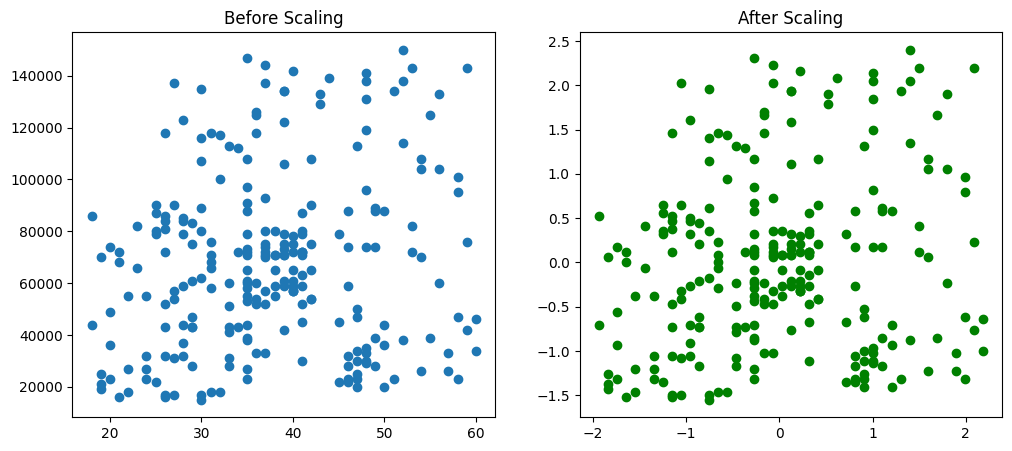

In [52]:
fig, (ax1, ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='green')
ax2.set_title("After Scaling")
plt.show()

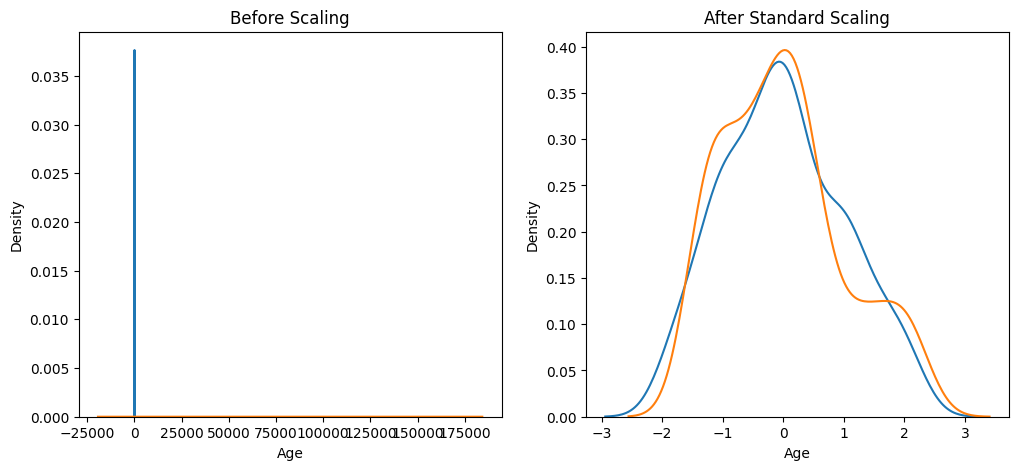

In [54]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Comparison of Distribution

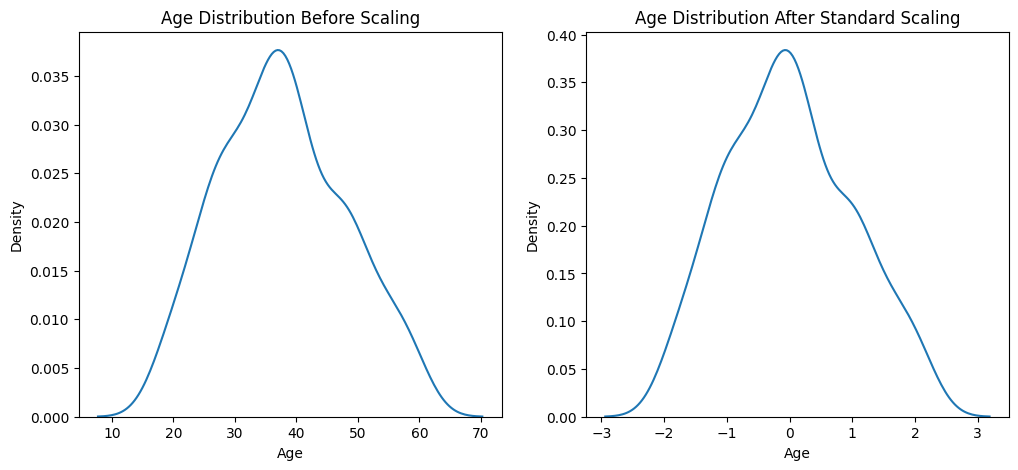

In [56]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
plt.show()

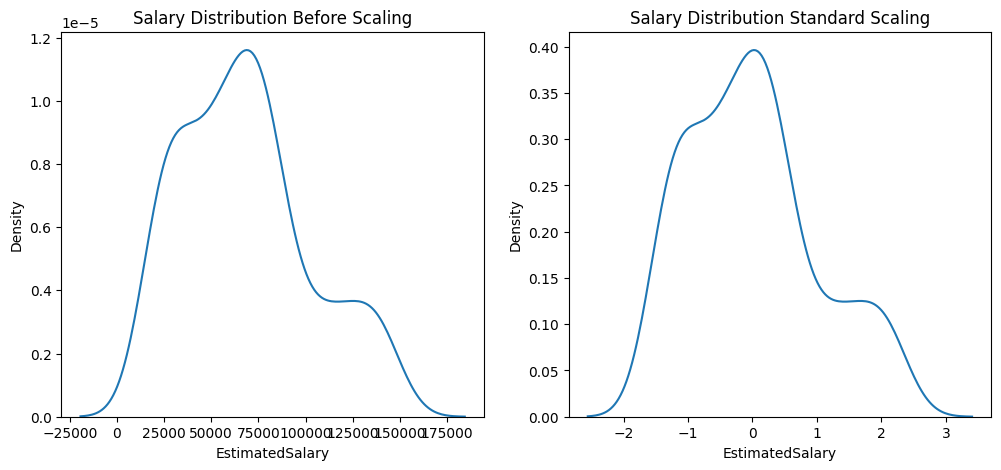

In [58]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Why Scalling is importanr?

In [61]:
from sklearn.linear_model import LogisticRegression

In [64]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [65]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [66]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [68]:
from sklearn.metrics import accuracy_score

In [69]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8625
Scaled 0.85625


In [70]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [73]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [76]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.88125
Scaled 0.88125


In [77]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


# Effect of Outlier

In [79]:
df = pd.concat([df, pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})], ignore_index=True)

In [80]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510.0,Male,19,19000,0
1,15810944.0,Male,35,20000,0
2,15668575.0,Female,26,43000,0
3,15603246.0,Female,27,57000,0
4,15804002.0,Male,19,76000,0
...,...,...,...,...,...
398,15755018.0,Male,36,33000,0
399,15594041.0,Female,49,36000,1
400,NaN,NaN,5,1000,0
401,NaN,NaN,90,250000,1


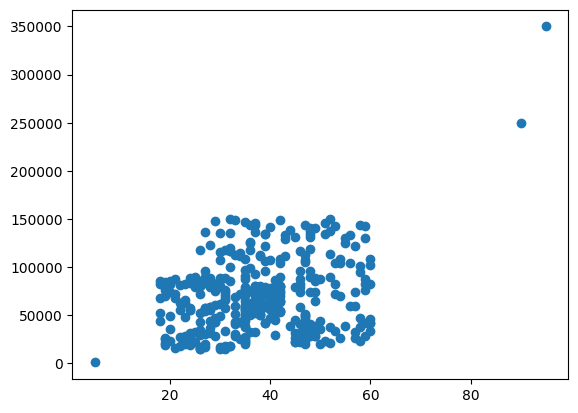

In [81]:
plt.scatter(df['Age'], df['EstimatedSalary'])